In [27]:
import re
import nltk
import string
from nltk.corpus import stopwords

import pandas as pd
import numpy as np

from keras.models import Model
from keras.utils import pad_sequences
from keras.preprocessing.text import Tokenizer
from keras.layers import Conv1D, MaxPooling1D, Embedding, Concatenate, Dense, Input, Flatten

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

In [2]:
Max_sequence_length = 100
Embedding_dim = 100

In [32]:
data = pd.read_csv('ISEAR_Dataset.csv')

In [33]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7516 entries, 0 to 7515
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   sentiment   7516 non-null   object
 1   content     7516 non-null   object
 2   Unnamed: 2  3 non-null      object
dtypes: object(3)
memory usage: 176.3+ KB


In [6]:
data.head()

,sentiment,content,Unnamed: 2
2457,joy,I felt glad to live again when I went to a mee...,NaN
2535,shame,"Walking on the street passing by an air duct, ...",NaN
279,guilt,When I broke off with my boyfriend after three...,NaN
807,guilt,"Car accident, hurt three of my closest family.",NaN
1958,sadness,"At end of school - function to ""celebrate"" ? L...",NaN


In [7]:
data['sentiment'].value_counts()

joy        728
fear       724
sadness    722
disgust    721
shame      706
guilt      705
anger      694
Name: sentiment, dtype: int64

In [8]:
def actual_tag(string):
    if string.startswith('J'):
        return nltk.corpus.wordnet.ADJ
    elif string.startswith('V'):
        return nltk.corpus.wordnet.VERB
    elif string.startswith('N'):
        return nltk.corpus.wordnet.NOUN
    elif string.startswith('R'):
        return nltk.corpus.wordnet.ADV
    else:
        return nltk.corpus.wordnet.NOUN

In [9]:
def lemmatize(array):
    opt_list = []
    wl = nltk.WordNetLemmatizer()
    stop = stopwords.words('english')
    stop += list(string.punctuation)
    for tple in array:
        word, tag = tple
        if word.lower() not in stop and word.isalpha():
            temp = wl.lemmatize(word,actual_tag(tag))
            opt_list.append(temp.lower())
    return opt_list

In [10]:
def preprocess(text):
    text = nltk.tokenize.word_tokenize(text)
    text = nltk.pos_tag(text)
    text = lemmatize(text)
    return text
    

In [11]:
processed_data = data['content'].map(preprocess)

In [12]:
processed_data.head()

2457    [felt, glad, live, go, meeting, knowledge, tec...
2535     [walking, street, passing, air, duct, skirt, go]
279     [break, boyfriend, three, year, quite, unexpec...
807           [car, accident, hurt, three, close, family]
1958    [end, school, function, celebrate, leaving, fr...
Name: content, dtype: object

In [13]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(processed_data)
sequences = tokenizer.texts_to_sequences(processed_data)

word_index = tokenizer.word_index
len(word_index)

5725

In [14]:
max([len(i) for i in sequences])

78

In [15]:
features = pad_sequences(sequences, Max_sequence_length)
labels = pd.get_dummies(data['sentiment'])

features.shape, labels.shape

((5000, 100), (5000, 7))

In [16]:
labels.head()

,anger,disgust,fear,guilt,joy,sadness,shame
2457,0,0,0,0,1,0,0
2535,0,0,0,0,0,0,1
279,0,0,0,1,0,0,0
807,0,0,0,1,0,0,0
1958,0,0,0,0,0,1,0


In [17]:
x_train, x_test, y_train, y_test = train_test_split(features, labels, test_size = 0.2, random_state = 5)
x_val, x_test, y_val, y_test = train_test_split(features, labels, test_size=0.5, random_state = 7)

In [18]:
embedding_layer = Embedding(len(word_index)+1,Embedding_dim, 
                            input_length=Max_sequence_length)

In [22]:
convs = []
filter_sizes = [3,4,5]

sequence_input = Input(shape=(Max_sequence_length,))
embedded_sequences = embedding_layer(sequence_input)

for fsz in filter_sizes:
    l_conv = Conv1D(128,fsz,activation='relu')(embedded_sequences)
    l_pool = MaxPooling1D(5)(l_conv)
    convs.append(l_pool)   
l_merge = Concatenate()(convs)
l_cov1= Conv1D(filters=128, kernel_size=5, activation='relu')(l_merge)
l_pool1 = MaxPooling1D(5)(l_cov1)
# l_cov2 = Conv1D(filters=128, kernel_size=5, activation='relu')(l_pool1)
# l_pool2 = MaxPooling1D(30)(l_cov2)
l_flat = Flatten()(l_pool1)
l_dense = Dense(128, activation='relu')(l_flat)
preds = Dense(7, activation='softmax')(l_dense)

model = Model(sequence_input, preds)
model.compile(loss='binary_crossentropy',
              optimizer='Nadam',
              metrics=['acc'])

model.summary()


Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_2 (InputLayer)        [(None, 100)]                0         []                            
                                                                                                  
 embedding (Embedding)       (None, 100, 100)             572600    ['input_2[0][0]']             
                                                                                                  
 conv1d_4 (Conv1D)           (None, 98, 128)              38528     ['embedding[1][0]']           
                                                                                                  
 conv1d_5 (Conv1D)           (None, 97, 128)              51328     ['embedding[1][0]']           
                                                                                            

In [23]:
history = model.fit(x_train, y_train, validation_data=(x_val,y_val), batch_size = 150, epochs=25, verbose=1)

Epoch 1/25
27/27 [==============================] - 7s 169ms/step - loss: 0.4557 - acc: 0.1370 - val_loss: 0.4094 - val_acc: 0.1484
Epoch 2/25
27/27 [==============================] - 4s 151ms/step - loss: 0.4074 - acc: 0.1692 - val_loss: 0.4031 - val_acc: 0.2264
Epoch 3/25
27/27 [==============================] - 4s 141ms/step - loss: 0.3890 - acc: 0.2582 - val_loss: 0.3693 - val_acc: 0.3056
Epoch 4/25
27/27 [==============================] - 4s 148ms/step - loss: 0.3499 - acc: 0.3805 - val_loss: 0.3231 - val_acc: 0.5048
Epoch 5/25
27/27 [==============================] - 4s 150ms/step - loss: 0.2962 - acc: 0.5310 - val_loss: 0.2739 - val_acc: 0.6320
Epoch 6/25
27/27 [==============================] - 4s 148ms/step - loss: 0.2368 - acc: 0.6810 - val_loss: 0.2228 - val_acc: 0.7144
Epoch 7/25
27/27 [==============================] - 4s 146ms/step - loss: 0.1764 - acc: 0.7878 - val_loss: 0.1832 - val_acc: 0.7812
Epoch 8/25
27/27 [==============================] - 4s 146ms/step - loss: 0.

dict_keys(['loss', 'acc', 'val_loss', 'val_acc'])


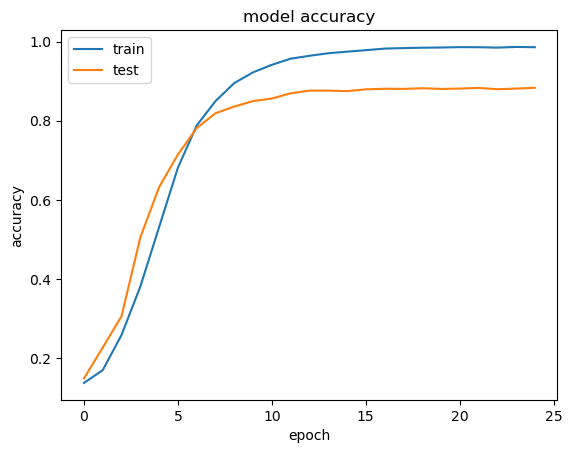

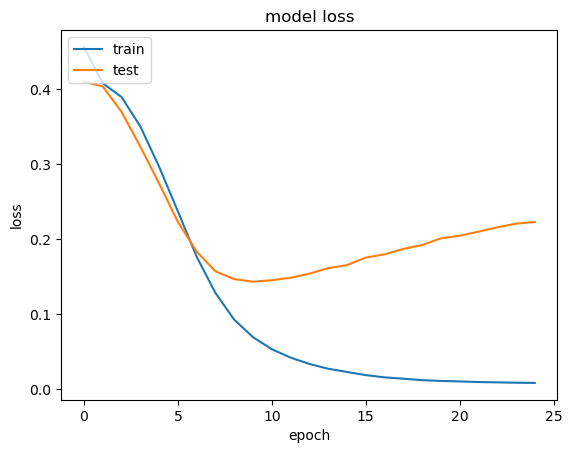

In [24]:
import matplotlib.pyplot as plt
%matplotlib inline 
# list all data in history
print(history.history.keys())
# summarize history for accuracy
plt.plot(history.history['acc'])
plt.plot(history.history['val_acc'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()
# summarize history for loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

In [29]:
y_pred = model.predict(x_test, verbose=1)

79/79 [==============================] - 1s 9ms/step


In [30]:
arr = np.argmax(np.asarray(y_test), axis=1)
ans = np.argmax(y_pred, axis=1)
f1 = f1_score(arr,ans, average='micro')
r1 = recall_score(arr, ans, average='micro')
p1 = precision_score(arr,ans, average='micro')
acc = accuracy_score(arr,ans)
print('f1',f1)
print('r1',r1)
print('p1',p1)
print('acc',acc)

f1 0.8908000000000001
r1 0.8908
p1 0.8908
acc 0.8908


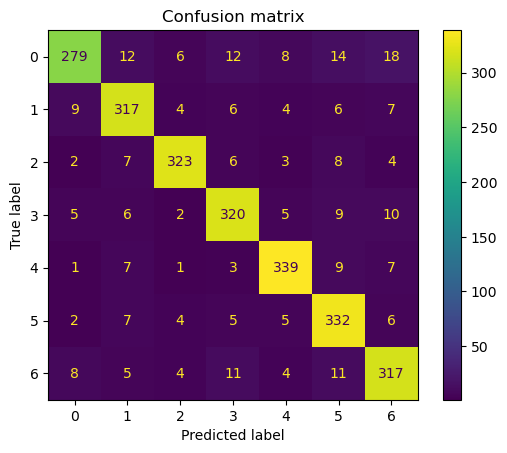

In [31]:
cm = confusion_matrix(arr, ans)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(set(arr)))
disp.plot()
plt.title("Confusion matrix")
plt.show()